In [44]:
# Cell 1: Environment check + install what we need
!pip install streamlit -q

import torch
import pandas as pd
import numpy as np
import sklearn

print("PyTorch version:", torch.__version__)
print("CUDA available (GPU):", torch.cuda.is_available())
print("Pandas version:", pd.__version__)
print("All core libraries loaded successfully ✅")

PyTorch version: 2.11.0+cu128
CUDA available (GPU): True
Pandas version: 2.2.3
All core libraries loaded successfully ✅


In [45]:
# Cell 2: Download a single day's traffic file from the official AWS-hosted CIC-IDS-2018 dataset
!pip install awscli -q

# List available files first, just so we can see what's there (optional, informative)
!aws s3 ls --no-sign-request "s3://cse-cic-ids2018/Processed Traffic Data for ML Algorithms/"

2018-10-11 16:02:25          0 
2018-10-11 16:02:49  352368373 Friday-02-03-2018_TrafficForML_CICFlowMeter.csv
2018-10-11 16:03:10  333723605 Friday-16-02-2018_TrafficForML_CICFlowMeter.csv
2018-10-11 16:03:33  382840456 Friday-23-02-2018_TrafficForML_CICFlowMeter.csv
2018-10-11 16:03:59 4054925350 Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv
2018-10-11 16:08:38  107842858 Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv
2018-10-11 16:08:48  375945899 Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv
2018-10-11 16:09:20  382636202 Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv
2018-10-11 16:09:44  358223333 Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv
2018-10-11 16:10:12  328893673 Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv
2018-10-11 16:10:33  209249758 Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv


In [46]:
# Cell 3: Download only Friday-02-03-2018 (contains Benign + Bot + DoS attack traffic)
!aws s3 cp --no-sign-request \
  "s3://cse-cic-ids2018/Processed Traffic Data for ML Algorithms/Friday-02-03-2018_TrafficForML_CICFlowMeter.csv" \
  "/content/friday_traffic.csv"

download: s3://cse-cic-ids2018/Processed Traffic Data for ML Algorithms/Friday-02-03-2018_TrafficForML_CICFlowMeter.csv to ./friday_traffic.csv


In [47]:
# Cell 4: Load and do a first look at the dataset
import pandas as pd

df = pd.read_csv("/content/friday_traffic.csv")

print("Shape (rows, columns):", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Shape (rows, columns): (1048575, 80)

Column names:
['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b

In [48]:
# Cell 5: Look at the label column specifically
print("Unique labels and their counts:")
print(df['Label'].value_counts())

Unique labels and their counts:
Label
Benign    762384
Bot       286191
Name: count, dtype: int64


In [49]:

df.head()

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,443,6,02/03/2018 08:47:38,141385,9,7,553,3773.0,202,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,49684,6,02/03/2018 08:47:38,281,2,1,38,0.0,38,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,443,6,02/03/2018 08:47:40,279824,11,15,1086,10527.0,385,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,443,6,02/03/2018 08:47:40,132,2,0,0,0.0,0,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,443,6,02/03/2018 08:47:41,274016,9,13,1285,6141.0,517,0,...,20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


In [50]:
# Cell 7: Check for data quality issues we'll need to handle in Step 5
print("Any missing values per column (top 10):")
print(df.isnull().sum().sort_values(ascending=False).head(10))

print("\nData types summary:")
print(df.dtypes.value_counts())

Any missing values per column (top 10):
Flow Byts/s        2558
Dst Port              0
Timestamp             0
Protocol              0
Tot Fwd Pkts          0
Tot Bwd Pkts          0
TotLen Fwd Pkts       0
Flow Duration         0
Fwd Pkt Len Max       0
Fwd Pkt Len Min       0
dtype: int64

Data types summary:
int64      41
float64    37
object      2
Name: count, dtype: int64


In [51]:
# Cell 8: Encode the label column (text -> number)
df['Label'] = df['Label'].map({'Benign': 0, 'Bot': 1})
print("Label encoding check:")
print(df['Label'].value_counts())

Label encoding check:
Label
0    762384
1    286191
Name: count, dtype: int64


In [52]:
# Cell 9: Check for infinite values (these hide from isnull())
import numpy as np

inf_counts = np.isinf(df.select_dtypes(include=[np.number])).sum()
print("Columns with infinite values:")
print(inf_counts[inf_counts > 0])

Columns with infinite values:
Flow Byts/s    1492
Flow Pkts/s    4050
dtype: int64


In [53]:
# Cell 10: Replace infinities with NaN, then handle all missing values together
df.replace([np.inf, -np.inf], np.nan, inplace=True)

print("Total missing values after converting infinities to NaN:", df.isnull().sum().sum())
print("As a percentage of total rows:", round(df.isnull().sum().sum() / len(df) * 100, 4), "%")

# Since missing values are a tiny fraction of ~1 million rows, we simply drop those rows
df.dropna(inplace=True)
print("\nShape after dropping missing/infinite rows:", df.shape)

Total missing values after converting infinities to NaN: 8100
As a percentage of total rows: 0.7725 %

Shape after dropping missing/infinite rows: (1044525, 80)


In [54]:
# Cell 11: Drop columns that are NOT useful as model features
# Timestamp: needed for ORDERING our data (Step 7), but not fed into the model as a feature itself
# We keep it separately for now, don't drop yet — just noting it

# These columns are typically constant or near-useless in this dataset (all/mostly one value)
# Let's check before dropping anything blindly
print("Columns with only 1 unique value (safe to drop, they carry no information):")
nunique = df.nunique()
constant_cols = nunique[nunique == 1].index.tolist()
print(constant_cols)

Columns with only 1 unique value (safe to drop, they carry no information):
['Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'CWE Flag Count', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg']


In [55]:
# Cell 12: Drop the truly constant columns (if any found above)
df.drop(columns=constant_cols, inplace=True)
print("Shape after dropping constant columns:", df.shape)

Shape after dropping constant columns: (1044525, 70)


In [56]:
# Cell 13: Separate columns into their roles: timestamp, label, and candidate features
print("Total columns:", len(df.columns))
print("\nDtypes of remaining object (non-numeric) columns:")
print(df.select_dtypes(include=['object']).dtypes)

Total columns: 70

Dtypes of remaining object (non-numeric) columns:
Timestamp    object
dtype: object


In [57]:
# Cell 14: Check Dst Port and Protocol - are they truly numeric-behaving, or categorical?
print("Unique Protocol values:", df['Protocol'].nunique())
print(df['Protocol'].value_counts())

print("\nUnique Dst Port values:", df['Dst Port'].nunique())
print(df['Dst Port'].value_counts().head(10))

Unique Protocol values: 3
Protocol
6     828442
17    202701
0      13382
Name: count, dtype: int64

Unique Dst Port values: 37271
Dst Port
8080    281637
53      192905
3389    177448
80      110411
443      94606
445      41706
0        13382
5355      4579
137       1641
67         707
Name: count, dtype: int64


In [58]:
# Cell 15: Convert Timestamp to a proper datetime, and SORT the dataframe by it
# This is critical for forecasting - our sequences must be in true chronological order
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%d/%m/%Y %H:%M:%S')
df = df.sort_values('Timestamp').reset_index(drop=True)

print("Earliest timestamp:", df['Timestamp'].min())
print("Latest timestamp:", df['Timestamp'].max())
print("Total time span:", df['Timestamp'].max() - df['Timestamp'].min())

Earliest timestamp: 2018-03-02 01:00:00
Latest timestamp: 2018-03-02 12:59:59
Total time span: 0 days 11:59:59


In [59]:
# Cell 16: Define our final feature list explicitly (excluding Timestamp and Label)
feature_cols = [col for col in df.columns if col not in ['Timestamp', 'Label']]
print("Number of features selected:", len(feature_cols))
print("\nFeature list:")
print(feature_cols)

Number of features selected: 68

Feature list:
['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Subflow Fwd Pkts', 'Subflow Fwd Byts', 'Subflow Bwd Pkts', 'Subflow Bwd Byts', 'Init Fwd Win Byts

In [60]:
# Cell 17: Check how Bot traffic is distributed across the day, hour by hour
df['Hour'] = df['Timestamp'].dt.hour
hourly_labels = df.groupby(['Hour', 'Label']).size().unstack(fill_value=0)
hourly_labels.columns = ['Benign', 'Bot']
print(hourly_labels)

      Benign    Bot
Hour               
1      79543  32146
2      75517  41585
3      83417  67560
4      74936      0
5      45588      0
8      36704      0
9      97399      0
10     92213  25648
11     95371  87412
12     77646  31840


In [61]:
# Cell 18: Slice a contiguous, manageable subset spanning the calm -> attack transition
subset = df[df['Hour'].isin([9, 10, 11])].copy()
subset = subset.sort_values('Timestamp').reset_index(drop=True)

print("Subset shape:", subset.shape)
print("\nLabel counts in subset:")
print(subset['Label'].value_counts())

Subset shape: (398043, 71)

Label counts in subset:
Label
0    284983
1    113060
Name: count, dtype: int64


In [62]:
# Cell 19: Trim to a faster, still-genuine subset for rapid development
subset_small = subset.iloc[::3].reset_index(drop=True)

print("Trimmed subset shape:", subset_small.shape)
print("\nLabel counts:")
print(subset_small['Label'].value_counts())

Trimmed subset shape: (132681, 71)

Label counts:
Label
0    95014
1    37667
Name: count, dtype: int64


In [63]:
# Cell 20: Chronological split - train (70%) / validation (15%) / test (15%)
n = len(subset_small)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = subset_small.iloc[:train_end].reset_index(drop=True)
val_df   = subset_small.iloc[train_end:val_end].reset_index(drop=True)
test_df  = subset_small.iloc[val_end:].reset_index(drop=True)

print("Train shape:", train_df.shape, "| time range:", train_df['Timestamp'].min(), "to", train_df['Timestamp'].max())
print("Val shape:  ", val_df.shape,   "| time range:", val_df['Timestamp'].min(), "to", val_df['Timestamp'].max())
print("Test shape: ", test_df.shape,  "| time range:", test_df['Timestamp'].min(), "to", test_df['Timestamp'].max())

print("\nLabel balance per split:")
print("Train:", train_df['Label'].value_counts(normalize=True).round(3).to_dict())
print("Val:  ", val_df['Label'].value_counts(normalize=True).round(3).to_dict())
print("Test: ", test_df['Label'].value_counts(normalize=True).round(3).to_dict())

Train shape: (92876, 71) | time range: 2018-03-02 09:00:00 to 2018-03-02 11:18:42
Val shape:   (19902, 71) | time range: 2018-03-02 11:18:42 to 2018-03-02 11:32:36
Test shape:  (19903, 71) | time range: 2018-03-02 11:32:36 to 2018-03-02 11:59:59

Label balance per split:
Train: {0: 0.791, 1: 0.209}
Val:   {1: 0.573, 0: 0.427}
Test:  {0: 0.657, 1: 0.343}


In [64]:
print(subset.shape)

(398043, 71)


In [65]:
subset_small = subset.iloc[::3].reset_index(drop=True)

print("Trimmed subset shape:", subset_small.shape)
print("\nLabel counts:")
print(subset_small['Label'].value_counts())

Trimmed subset shape: (132681, 71)

Label counts:
Label
0    95014
1    37667
Name: count, dtype: int64


In [66]:
n = len(subset_small)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = subset_small.iloc[:train_end].reset_index(drop=True)
val_df   = subset_small.iloc[train_end:val_end].reset_index(drop=True)
test_df  = subset_small.iloc[val_end:].reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (92876, 71)
Val shape: (19902, 71)
Test shape: (19903, 71)


In [67]:
print(train_df.dtypes)

Dst Port                  int64
Protocol                  int64
Timestamp        datetime64[ns]
Flow Duration             int64
Tot Fwd Pkts              int64
                      ...      
Idle Std                float64
Idle Max                float64
Idle Min                float64
Label                     int64
Hour                      int32
Length: 71, dtype: object


In [68]:
from sklearn.preprocessing import StandardScaler

# Remove Timestamp and Label from the input features
feature_cols = [col for col in train_df.columns
                if col not in ['Timestamp', 'Label']]

# Create the feature data
X_train = train_df[feature_cols]
X_val   = val_df[feature_cols]
X_test  = test_df[feature_cols]

# Create the scaler
scaler = StandardScaler()

# IMPORTANT: fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler for validation and test
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Number of features:", len(feature_cols))
print("Train shape:", X_train_scaled.shape)
print("Validation shape:", X_val_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Number of features: 69
Train shape: (92876, 69)
Validation shape: (19902, 69)
Test shape: (19903, 69)


In [69]:
import numpy as np

SEQ_LEN = 10

def create_sequences(X, labels, seq_len):
    X_seq = []
    y_seq = []

    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i + seq_len])
        y_seq.append(labels[i + seq_len])

    return np.array(X_seq), np.array(y_seq)


# Get labels
y_train = train_df['Label'].values
y_val   = val_df['Label'].values
y_test  = test_df['Label'].values

# Create sequences
X_train_seq, y_train_seq = create_sequences(
    X_train_scaled, y_train, SEQ_LEN
)

X_val_seq, y_val_seq = create_sequences(
    X_val_scaled, y_val, SEQ_LEN
)

X_test_seq, y_test_seq = create_sequences(
    X_test_scaled, y_test, SEQ_LEN
)

print("X_train:", X_train_seq.shape)
print("y_train:", y_train_seq.shape)

print("X_val:", X_val_seq.shape)
print("y_val:", y_val_seq.shape)

print("X_test:", X_test_seq.shape)
print("y_test:", y_test_seq.shape)

X_train: (92866, 10, 69)
y_train: (92866,)
X_val: (19892, 10, 69)
y_val: (19892,)
X_test: (19893, 10, 69)
y_test: (19893,)


In [70]:
print("One sequence shape:", X_train_seq[0].shape)

print("\nFirst sequence:")
print(X_train_seq[0])

print("\nTarget for this sequence:")
print(y_train_seq[0])

One sequence shape: (10, 69)

First sequence:
[[-5.07730603e-01 -5.27857630e-01 -3.89830538e-01 -4.39046339e-02
  -5.32954424e-02 -2.48479382e-01 -2.81513328e-02 -7.52425025e-01
  -4.62522193e-01 -9.28830288e-01 -7.46493905e-01 -6.83254955e-01
  -4.83363892e-01 -6.10747111e-01 -6.22594319e-01 -7.38348276e-02
  -9.56910770e-03 -2.38752995e-01 -2.46070310e-01 -3.39113415e-01
  -2.12037277e-01 -3.80977854e-01 -2.55632388e-01 -2.51802650e-01
  -3.30336351e-01 -2.16016927e-01 -2.91320503e-01 -2.21863894e-01
  -2.52155458e-01 -2.47267333e-01 -6.43216354e-02 -1.93500578e-01
  -2.27481614e-02 -5.66219978e-02  9.95701871e-03 -7.13066611e-02
  -4.84937892e-01 -7.49444063e-01 -6.64226559e-01 -7.35416796e-01
  -4.64522755e-01 -5.91670070e-02 -1.93500578e-01 -5.29539880e-01
  -8.64313229e-01  1.45847113e+00 -1.99062007e-01 -5.29539880e-01
  -7.92168341e-01 -7.32165307e-01 -9.28830288e-01 -6.10747111e-01
  -4.39046339e-02 -2.48479382e-01 -5.32954424e-02 -2.81433604e-02
  -5.01447130e-01 -4.38520020e

In [71]:
X_train_seq = X_train_seq.astype(np.float32)
X_val_seq = X_val_seq.astype(np.float32)
X_test_seq = X_test_seq.astype(np.float32)

print("Train:", X_train_seq.shape)
print("Validation:", X_val_seq.shape)
print("Test:", X_test_seq.shape)

Train: (92866, 10, 69)
Validation: (19892, 10, 69)
Test: (19893, 10, 69)


In [72]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(10, 69)),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        34,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,369 (134.25 KB)

 Trainable params: 34,369 (134.25 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
history = model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_val_seq, y_val_seq),
    epochs=5,
    batch_size=128
)

Epoch 1/5
726/726 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8418 - loss: 0.3328 - precision: 0.6412 - recall: 0.5556 - val_accuracy: 0.6629 - val_loss: 0.6277 - val_precision: 0.6870 - val_recall: 0.7555
Epoch 2/5
726/726 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8452 - loss: 0.3210 - precision: 0.6535 - recall: 0.5552 - val_accuracy: 0.6621 - val_loss: 0.6275 - val_precision: 0.6911 - val_recall: 0.7410
Epoch 3/5
726/726 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8460 - loss: 0.3192 - precision: 0.6577 - recall: 0.5521 - val_accuracy: 0.6637 - val_loss: 0.6243 - val_precision: 0.6811 - val_recall: 0.7759
Epoch 4/5
726/726 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8472 - loss: 0.3170 - precision: 0.6628 - recall: 0.5508 - val_accuracy: 0.6671 - val_loss: 0.6233 - val_precision: 0.6742 - val_recall: 0.8098
Epoch 5/5
726/726 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8482 - loss: 0.3155 - precision: 0.6655 - recall: 0.5539 - val_accuracy: 0.6627 - val_loss: 0.6269 

In [74]:
y_test_prob = model.predict(X_test_seq)

print("Prediction shape:", y_test_prob.shape)
print("First 10 probabilities:")
print(y_test_prob[:10].flatten())

622/622 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Prediction shape: (19893, 1)
First 10 probabilities:
[0.73360854 0.5879379  0.7060897  0.71702445 0.72393274 0.72874826
 0.7051444  0.7135821  0.7345276  0.73149323]


In [75]:
import numpy as np

y_test_pred = (y_test_prob >= 0.5).astype(int).flatten()

print("Predictions shape:", y_test_pred.shape)
print("First 20 predictions:")
print(y_test_pred[:20])

print("\nActual first 20 labels:")
print(y_test_seq[:20])

Predictions shape: (19893,)
First 20 predictions:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Actual first 20 labels:
[0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1]


In [76]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy = accuracy_score(y_test_seq, y_test_pred)
precision = precision_score(y_test_seq, y_test_pred)
recall = recall_score(y_test_seq, y_test_pred)
f1 = f1_score(y_test_seq, y_test_pred)

cm = confusion_matrix(y_test_seq, y_test_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

print("\nConfusion Matrix:")
print(cm)

Accuracy : 0.6730508218971497
Precision: 0.5236386331721017
Recall   : 0.4930218892316733
F1 Score : 0.5078692493946732

Confusion Matrix:
[[10033  3053]
 [ 3451  3356]]


In [77]:
tn, fp, fn, tp = cm.ravel()

fpr = fp / (fp + tn)

print("True Negatives :", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives :", tp)

print("\nFalse Positive Rate:", fpr)
print("False Positive Rate (%):", fpr * 100)

True Negatives : 10033
False Positives: 3053
False Negatives: 3451
True Positives : 3356

False Positive Rate: 0.23330276631514596
False Positive Rate (%): 23.330276631514597


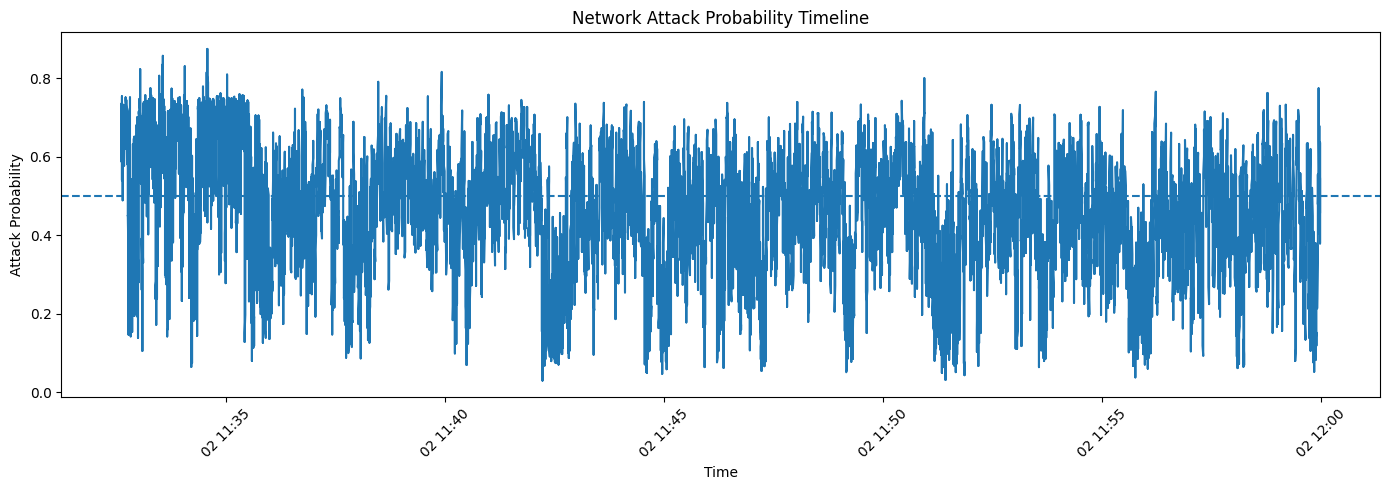

In [78]:
import matplotlib.pyplot as plt

test_timestamps = test_df['Timestamp'].iloc[SEQ_LEN:].reset_index(drop=True)

plt.figure(figsize=(14, 5))

plt.plot(
    test_timestamps,
    y_test_prob.flatten()
)

plt.axhline(
    y=0.5,
    linestyle='--'
)

plt.xlabel("Time")
plt.ylabel("Attack Probability")
plt.title("Network Attack Probability Timeline")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [79]:
import joblib

# Save the trained LSTM model
model.save("attack_forecasting_lstm.keras")

# Save the scaler
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully!")
print("Scaler saved successfully!")

Model saved successfully!
Scaler saved successfully!


In [80]:
from google.colab import files

files.download("attack_forecasting_lstm.keras")
files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [81]:
subset_small.to_csv("network_traffic_subset.csv", index=False)

print("CSV saved successfully!")
print(subset_small.shape)


CSV saved successfully!
(132681, 71)


In [82]:
from google.colab import files

files.download("network_traffic_subset.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>